<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/An%C3%A1lisis%20Exploratorio%20y%20Curaci%C3%B3n%20de%20Datos/parte%201/ECD_2026_Entregable_Parte_1_grupo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**


----

# Trabajo práctico entregable - parte 1


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA

sns.set_context('talk')

In [54]:
# Cargamos los datos
melb_data = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_data[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


### Información acerca de las variables
`Suburb`: Suburb

`Address`: Dirección

`Rooms`: Número de habitaciones

`Price`: Precio en dólares australianos

`Method`:
S - propiedad vendida;
SP - propiedad vendida previamente;
PI - propiedad no vendida (pasó en subasta sin alcanzar el precio de reserva);
PN - vendida previamente no divulgada;
SN - vendida no divulgada;
NB - sin oferta;
VB - oferta del vendedor;
W - retirada antes de la subasta;
SA - vendida después de la subasta;
SS - vendida después de la subasta (precio no divulgado).
N/A - precio o oferta más alta no disponible.

`Type`:
br - dormitorio(s);
h - casa, cabaña, villa, semi-adosado, terraza;
u - unidad, dúplex;
t - casa adosada;
dev site - sitio de desarrollo;
o res - otra residencia.

`SellerG`: Agente inmobiliario

`Date`: Fecha de venta

`Distance`: Distancia al CBD en kilómetros

`Regionname`: Región general (Oeste, Noroeste, Norte, Noreste, etc.)

`Propertycount`: Número de propiedades existentes en el suburbio.

`Bedroom2` : Número de dormitorios (obtenido de otra fuente)

`Bathroom`: Número de baños

`Car`: Número de plazas de aparcamiento

`Landsize`: Tamaño del terreno en metros cuadrados

`BuildingArea`: Superficie construida en metros cuadrados

`YearBuilt`: Año de construcción de la casa

`CouncilArea`: Área del consejo municipal

`Lattitude`: Latitud

`Longtitude`: Longitud


In [55]:
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Decidir si elimina algunas filas o columnas en base al análisis de datos faltantes.

3. Hacer un análisis descriptivo de las variables numéricas del conjunto de datos. Todas tienen el tipo `Dtype` correcto asignado? Armar una matriz (array) sólo con las variables numéricas.  

4. Estudiar las variables categóricas del DataFrame. Aplicar una codificación One-hot encoding a las columnas categóricas que crea pertinente. Si lo consideran necesario, pueden reducir el número de categorías únicas de algunas variables. ¿Cómo trataría la variable `Date`? Armar la matriz de variables categóricas codificada.

5. Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


### Resolución Ejercicio 1

#### Análisis exploratorio previo

Antes de transformar los datos, exploramos su estructura, valores faltantes y ceros para tomar decisiones fundamentales sobre qué conservar, eliminar o corregir.

In [56]:
# Seleccion de columnas relevantes: no incluye BuildingArea ni YearBuilt
melb_df = melb_data.drop(['BuildingArea', 'YearBuilt'], axis=1).copy()
melb_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

In [57]:
# Ver cardinalidad de cada columna categórica
categorical_variables = melb_df.select_dtypes(include='object').columns
for col in categorical_variables:
    print(f"{col}: {melb_df[col].nunique()}")

Suburb: 314
Address: 13378
Type: 3
Method: 5
SellerG: 268
Date: 58
CouncilArea: 33
Regionname: 8


In [58]:
# Valores faltantes y ceros por columna
faltantes = melb_df.isna().sum()
ceros = (melb_df == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes, 'Ceros': ceros})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
Distance,0,6
Bedroom2,0,16
Bathroom,0,34
Car,62,1026
Landsize,0,1939
CouncilArea,1369,0


In [59]:
# Ver porcentaje de datos faltantes
faltantes = melb_df.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(1))

CouncilArea    10.1
Car             0.5
dtype: float64


Se observan 1026 registros de propiedades sin cochera, es decir con ```Car = 0```. Los 62 casos en los que ```Car = Null``` se descartan sin pérdida de generalidad.







In [60]:
# Eliminamos columnas faltantes en la variable Car
melb_df = melb_df.dropna(subset=['Car'])
melb_df.shape[0]

13518

In [61]:
missing_values_count = melb_df.isna().sum()
missing_values_count[missing_values_count > 0]

,0
CouncilArea,1307


Como `CouncilArea` es una variable categórica, se decidió conservar los casos faltantes creando una nueva categoría `Desconocido` para no perder observaciones.

In [62]:
melb_df['CouncilArea'] = melb_df['CouncilArea'].fillna('Desconocido')
# Conteo de valores faltantes
melb_df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


Estudio de los casos en los que `Distance = 0`

In [63]:
melb_df[melb_df['Distance'] == 0][['Suburb', 'Distance', 'Regionname']].head(10)

,Suburb,Distance,Regionname
9620,Melbourne,0.0,Northern Metropolitan
10393,Melbourne,0.0,Northern Metropolitan
10739,Melbourne,0.0,Northern Metropolitan
11428,Melbourne,0.0,Northern Metropolitan
12073,Melbourne,0.0,Northern Metropolitan
12074,Melbourne,0.0,Northern Metropolitan


Se analizaron los registros con `Distance = 0` y se observó que todos corresponden al suburbio Melbourne. Estos casos pueden interpretarse como propiedades ubicadas en el centro principal de la ciudad. Por lo tanto, se considera un valor válido y no un dato faltante codificado.

Estudio de la relación entre `Bedrooms2` y `Rooms`.

In [64]:
pd.crosstab(melb_df['Bedroom2'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.0,0,5,8,3,0,0,0,0,0
1.0,660,21,5,2,0,0,0,0,0
2.0,16,3513,162,19,1,0,0,0,0
3.0,2,74,5597,175,18,1,0,0,0
4.0,0,8,73,2469,42,4,0,1,0
5.0,0,1,5,15,531,2,2,0,0
6.0,0,0,0,0,2,59,0,2,0
7.0,0,0,0,0,1,1,8,0,0
8.0,0,0,0,0,1,0,0,4,0


Se observan muchos casos en los que `Bedroom2 > Rooms`, lo cual carece de sentido. No es posible tener una cantidad de dormitorios superior al número de ambientes que tiene la propiedad. Como `Bedroom2` se obtuvo de fuentes externas y la información que aporta distorciona la interpretación del dataset, se opta por eliminarla y conservar únicamente la columna `Rooms`.



In [65]:
melb_df = melb_df.drop('Bedroom2', axis=1)

Estudio de la relación entre `Bathroom` y `Rooms`.

In [66]:
pd.crosstab(melb_df['Bathroom'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.0,1,19,11,3,0,0,0,0,0
1.0,671,3093,3233,451,17,2,0,0,0
2.0,6,502,2447,1718,260,20,3,2,0
3.0,0,8,153,468,244,35,5,2,1
4.0,0,0,5,41,47,9,2,2,0
5.0,0,0,1,2,25,0,0,0,0
6.0,0,0,2,0,2,1,0,0,0
7.0,0,0,0,0,1,0,0,1,0
8.0,0,0,0,1,0,0,0,1,0


Se observan algunos puntos de interés en esta tabla:

- Casos `Bathroom > Rooms`: Extraño que una propiedad tenga más baños que ambientes, sería correcto eliminar.
- Casos `Bathroom = 0`: Puede ser un indicador de pobreza, aunque esto debe verificarse con los demás indicadores (pocos ambientes, construcción pequeña, etc). En casas grandes, se interpreta como error de tipeo.

Tratamiento: Se codifican como `NA` los casos `Bathroom = 0` para posteriormente eliminarlos. Del mismo modo, se eliminan los casos `Bathroom > Rooms`.

No se analiza el caso de ausencia de baños como posible indicador de pobreza.

In [67]:
melb_df.loc[melb_df['Bathroom'] < 1, 'Bathroom'] = pd.NA
melb_df.loc[melb_df['Bathroom'] > melb_df['Rooms'], 'Bathroom'] = pd.NA
melb_df = melb_df.dropna(subset=['Bathroom'])
melb_df.shape[0]

13456

Los casos `Landsize = 0` se consideran como dato faltante codificado. Tratamiento: se reemplazan por NaN y posteriormente se eliminan. Luego se eliminan outliers extremos utilizando percentiles.

También se eliminan las filas que no tienen precio, es decir `Price = 0` o `Price = Null`.

In [68]:
# Identificar cuantos casos hay en los que Landsize = 0
print(melb_df[melb_df['Landsize'] == 0].shape[0])
print(melb_df[melb_df['Price'] == 0].shape[0])
melb_df = melb_df[melb_df['Landsize'] != 0]
melb_df["Landsize"].describe()

1917
0


,Landsize
count,11539.000000
mean,651.594246
std,4320.362646
min,1.000000
25%,271.500000
50%,534.000000
75%,676.000000
max,433014.000000


In [69]:
# Eliminar outliers extremos
q99_landsize = melb_df['Landsize'].quantile(0.99)
melb_df = melb_df[(melb_df['Landsize'] < q99_landsize) | (melb_df['Landsize'].isnull())]
melb_df["Landsize"].describe()

,Landsize
count,11423.000000
mean,520.762147
std,343.757511
min,1.000000
25%,269.000000
50%,531.000000
75%,670.000000
max,3448.000000


<Axes: >

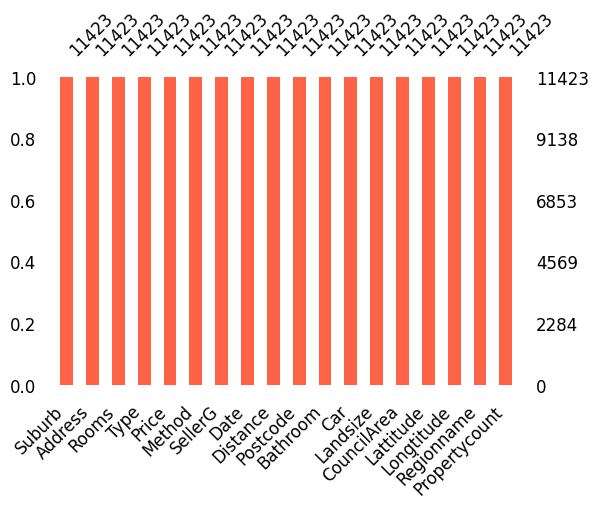

In [70]:
msno.bar(melb_df,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

#### Análisis descriptivo de variables numéricas

Verificamos los tipos de datos asignados y revisamos estadísticas descriptivas para detectar anomalías.

In [71]:
# Verificacion de types en las variables
melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


Corrección de tipos de variables: `Propertycount`, `Bathroom` y `Car` deben ser variables numéricas enteras en lugar de reales. `Postcode` debe ser una variable categórica, pues si fuera numérica podría obtener estadística descriptiva de sus valores lo cual no tendría sentido.

In [72]:
# Postcode como categórical
melb_df['Postcode'] = melb_df['Postcode'].astype(object)

# Propertycount como integer
melb_df['Propertycount'] = melb_df['Propertycount'].astype(int)

# Car como integer
melb_df['Car'] = melb_df['Car'].astype(int)

# Bathroom como integer
melb_df['Bathroom'] = melb_df['Bathroom'].astype(int)

melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,object


In [73]:
# Estadísticas descriptivas de variables numéricas
numerical_col = melb_df.select_dtypes(include='number').columns
melb_df[numerical_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,11423.0,3.110216e+00,0.889452,1.00000,3.000000,3.0000,4.000000e+00,1.000000e+01
Price,11423.0,1.149468e+06,647675.909130,131000.00000,715000.000000,975000.0000,1.400000e+06,9.000000e+06
Distance,11423.0,1.082244e+01,5.873969,0.00000,7.000000,10.4000,1.360000e+01,4.740000e+01
Bathroom,11423.0,1.582947e+00,0.695003,1.00000,1.000000,1.0000,2.000000e+00,8.000000e+00
Car,11423.0,1.694826e+00,0.989799,0.00000,1.000000,2.0000,2.000000e+00,1.000000e+01
Landsize,11423.0,5.207621e+02,343.757511,1.00000,269.000000,531.0000,6.700000e+02,3.448000e+03
Lattitude,11423.0,-3.780653e+01,0.082947,-38.17488,-37.857235,-37.7960,-3.774950e+01,-3.740853e+01
Longtitude,11423.0,1.449967e+02,0.110006,144.43181,144.923505,145.0041,1.450673e+02,1.455264e+02
Propertycount,11423.0,7.311815e+03,4400.101414,389.00000,4019.000000,6482.0000,9.758000e+03,2.165000e+04


In [74]:
# Estudio la cardinalidad de cada columna categórica post-limpieza
categorical_variables = melb_df.select_dtypes(include='object').columns
for col in categorical_variables:
    print(f"{col}: {melb_df[col].nunique()} valores únicos")

Suburb: 309 valores únicos
Address: 11250 valores únicos
Type: 3 valores únicos
Method: 5 valores únicos
SellerG: 251 valores únicos
Date: 58 valores únicos
Postcode: 194 valores únicos
CouncilArea: 34 valores únicos
Regionname: 8 valores únicos


Tratamiento de `Date` como fecha en lugar de objeto. Se discrimina el mes y el año de la venta en columnas independientes.

In [75]:
# Conversion a formato fecha
melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=True)

# Identificacion del año y mes en columnas nuevas
melb_df['SaleYear']  = melb_df['Date'].dt.year
melb_df['SaleMonth'] = melb_df['Date'].dt.month

# Descartar la columna original
melb_df = melb_df.drop(columns=['Date'], axis=1)

melb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11423 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         11423 non-null  object 
 1   Address        11423 non-null  object 
 2   Rooms          11423 non-null  int64  
 3   Type           11423 non-null  object 
 4   Price          11423 non-null  float64
 5   Method         11423 non-null  object 
 6   SellerG        11423 non-null  object 
 7   Distance       11423 non-null  float64
 8   Postcode       11423 non-null  object 
 9   Bathroom       11423 non-null  int64  
 10  Car            11423 non-null  int64  
 11  Landsize       11423 non-null  float64
 12  CouncilArea    11423 non-null  object 
 13  Lattitude      11423 non-null  float64
 14  Longtitude     11423 non-null  float64
 15  Regionname     11423 non-null  object 
 16  Propertycount  11423 non-null  int64  
 17  SaleYear       11423 non-null  int32  
 18  SaleMonth  

In [76]:
# Cantidad de ventas realizadas agrupadas por mes y discriminadas por año
melb_df.groupby(['SaleYear', 'SaleMonth']).size()

SaleYear  SaleMonth
2016      1               2
          2              22
          4             254
          5             706
          6             569
          7             350
          8             562
          9             732
          10            441
          11            889
          12            494
2017      2             347
          3             547
          4             509
          5            1004
          6            1000
          7            1355
          8             773
          9             867
dtype: int64

Los registros disponibles datan desde enero de 2016 hasta noviembre de 2017. Considerando los 24 meses de ambos años, es posible crear una variable categórica con 4 valores únicos que abarquen un rango semestral cada una.

NOTA: En lugar de codificación OneHot, en este caso podríamos utilizar codificación ordinal asignando `{2016_S1, 2016_S2, 2017_S1, 2017_S2} -> {1,2,3,4}`.

In [77]:
# Función simple para la lógica semestral
def asignar_semestre(row):
    semestre = "S1" if row['SaleMonth'] <= 6 else "S2"
    return f"{row['SaleYear']}_{semestre}"

In [78]:
# Aplicamos la función para crear la variable categórica
melb_df['Semester'] = melb_df.apply(asignar_semestre, axis=1)

# Contar elementos por categoria
melb_df['Semester'].value_counts()

,count
Semester,
2016_S2,3468
2017_S1,3407
2017_S2,2995
2016_S1,1553


In [79]:
# Elimino las columnas 'SaleYear' y 'SaleMonth'
melb_df = melb_df.drop(['SaleYear', 'SaleMonth'], axis=1)
melb_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'CouncilArea',
       'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'Semester'],
      dtype='object')

Estudio de variables numéricas. Matriz

In [80]:
# Seleccion de columnas numericas de interes
numerical_col = melb_df.select_dtypes(include='number').columns.tolist()

# Columnas que incluye numerical_col
print(numerical_col)

# Matriz con las columnas numericas
matrix_num = melb_df[numerical_col].values

# Mostrar contenido de la matriz numerica
print(matrix_num.shape)

['Rooms', 'Price', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount']
(11423, 9)


Tanto `Suburb`, `Address`, `CouncilArea`, `Postcode` como `Regionname` nos proveen información sobre la localización geográfica de la propiedad. Estudiaremos únicamente la variable categórica con menor cardinalidad de este grupo: `Regionname`.

Se aplica *One-Hot Encoding* únicamente a las variables `Type`, `Method`, `Regionname` y `Semester`

In [81]:
# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Seleccion de columnas categoricas de interes
categorical_col = ['Type', 'Method', 'Regionname', 'Semester']

matrix_cat = encoder.fit_transform(melb_df[categorical_col])

# Mostrar contenido de la matriz categorica
print(matrix_cat.shape)

(11423, 20)


In [82]:
# Columnas creadas
encoder.get_feature_names_out(categorical_col)

array(['Type_h', 'Type_t', 'Type_u', 'Method_PI', 'Method_S', 'Method_SA',
       'Method_SP', 'Method_VB', 'Regionname_Eastern Metropolitan',
       'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan',
       'Regionname_Northern Victoria',
       'Regionname_South-Eastern Metropolitan',
       'Regionname_Southern Metropolitan',
       'Regionname_Western Metropolitan', 'Regionname_Western Victoria',
       'Semester_2016_S1', 'Semester_2016_S2', 'Semester_2017_S1',
       'Semester_2017_S2'], dtype=object)

In [83]:
# Concatenación de ambas matrices
matrix_final = np.hstack([matrix_num, matrix_cat])
print(matrix_final.shape)

(11423, 29)


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer`, entre otros, para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [84]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

### Resolución Ejercicio 2

1. Agregamos las columnas de YearBuilt y BuildingArea del dataset original, con sus NaN originales.


*Aclaración*:

Si bien la consigna indica usar la matriz codificada completa (matrix_final), que incluye variables categóricas OHE, optamos por construir X_para_imputar a partir de matrix_num (solo variables numéricas) más YearBuilt y BuildingArea. Esto se debe a que IterativeImputer con KNeighborsRegressor imputa variables numéricas. Incluir las columnas OHE que son binarias y no tienen NaN no aporta información adicional y aumenta el costo computacional.

In [85]:
# 1. Agregamos YearBuilt y BuildingArea del dataset original con sus NaN
# Usamos melb_data (original) filtrado por el índice de melb_df (filas que sobrevivieron la limpieza)
extra_columns_df = melb_data.loc[melb_df.index, ['YearBuilt', 'BuildingArea']]
extra = extra_columns_df.values

# Verificamos cuántos NaN hay en cada columna
print("NaN en YearBuilt:", extra_columns_df['YearBuilt'].isna().sum())
print("NaN en BuildingArea:", extra_columns_df['BuildingArea'].isna().sum())

NaN en YearBuilt: 4625
NaN en BuildingArea: 5452


Se recuperan estas columnas desde melb_data (dataset original), filtrando únicamente las filas que sobrevivieron la limpieza del Ej 1 mediante melb_df.index. Esto garantiza que la matriz resultante tenga la misma cantidad de filas que matrix_num.



*   **YearBuilt**: 4625 valores faltantes (34% del dataset).
*   **BuildingArea**: 5452 valores faltantes (48% del dataset).

Dado el alto porcentaje de NaN, la elección del método de imputación es relevante: una imputación con media introduciría un sesgo en la distribución, mientras que KNN aprovecha la similitud entre propiedades para estimar valores más representativos.



2. ¿Es necesario estandarizar o escalar los datos previamente?

KNN imputa buscando las filas más similares a la que tiene el valor faltante, y usa esos vecinos para estimar el valor faltante.

El problema surge si una columna tiene valores entre 0 y 1.000.000 (como 'Price') y otra tiene entre 1 y 10 (como 'Rooms'), la distancia quedará dominada por Price. Las demás columnas no van a influir en qué vecinos se eligen, lo que lleva a una imputación sesgada.

Por eso se aplica 'MinMaxScaler' antes de imputar, que lleva a todos los valores al rango [0,1]. Así todas las variables contribuyen por igual al cálculo de distancias.

In [109]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Combinamos variables numéricas con YearBuilt y BuildingArea
X_para_imputar = np.hstack([matrix_num, extra])

# Escalamos antes de imputar
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_para_imputar)

# Imputación con la media (SimpleImputer) — referencia para comparar en el gráfico
simple_imputer = SimpleImputer(strategy='mean')
X_imputed_mean = simple_imputer.fit_transform(X_scaled)

# Imputación con KNN (IterativeImputer + KNeighborsRegressor)
knn_imputer = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=3),
    max_iter=20,
    tol=1e-3,
    random_state=42
)
X_imputed = knn_imputer.fit_transform(X_scaled)

print("Shape después de imputar:", X_imputed.shape)

Shape después de imputar: (11423, 11)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


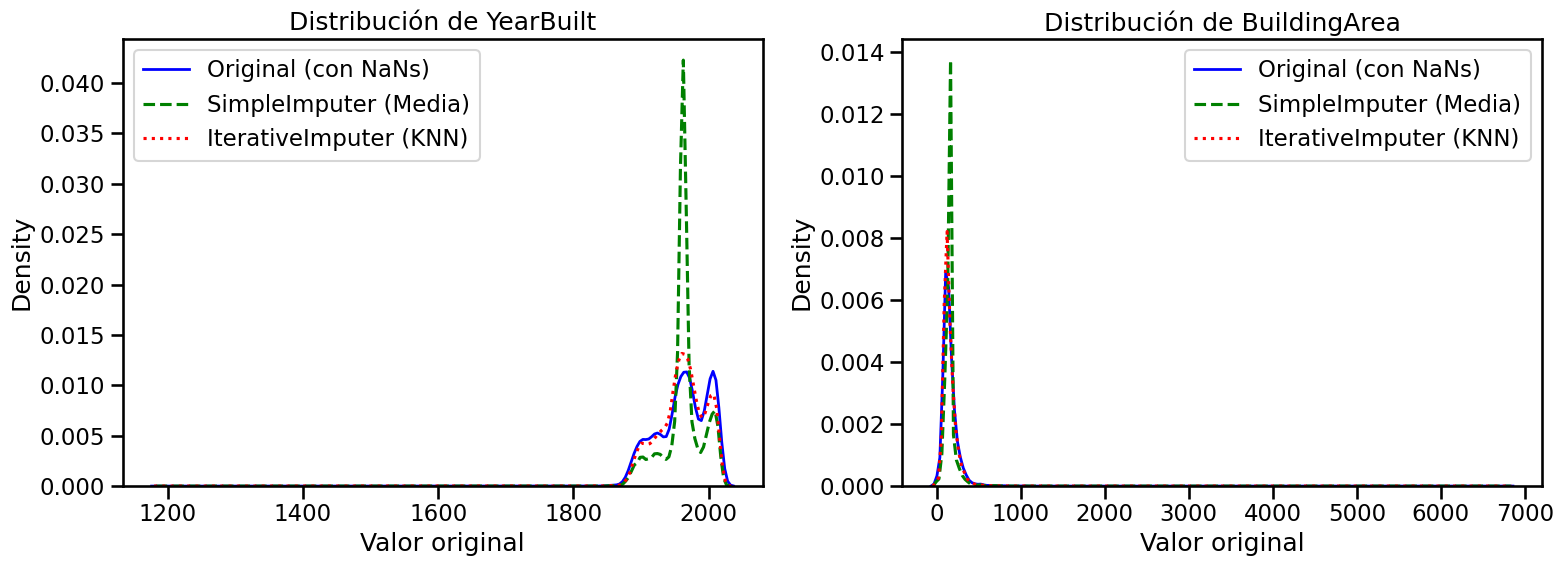

In [110]:
# 1. Volvemos a la escala original para que el gráfico sea interpretable
# Invertimos el escalado para la media y para KNN
X_mean_inv = scaler.inverse_transform(X_imputed_mean)
X_knn_inv = scaler.inverse_transform(X_imputed)

# Creamos DataFrames para facilitar el manejo de las columnas a graficar
# Asumimos que YearBuilt y BuildingArea son las últimas dos columnas de la matriz
cols_to_plot = ['YearBuilt', 'BuildingArea']
idx_year = -2
idx_area = -1

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col_name in enumerate(cols_to_plot):
    idx = idx_year if col_name == 'YearBuilt' else idx_area

    # Datos Originales (con NaNs, filtrados para el plot)
    sns.kdeplot(X_para_imputar[:, idx], label='Original (con NaNs)',
                ax=axes[i], color='blue', lw=2, common_norm=False)

    # Imputación Simple (Media)
    sns.kdeplot(X_mean_inv[:, idx], label='SimpleImputer (Media)',
                ax=axes[i], color='green', linestyle='--', common_norm=False)

    # Imputación KNN
    sns.kdeplot(X_knn_inv[:, idx], label='IterativeImputer (KNN)',
                ax=axes[i], color='red', linestyle=':', common_norm=False)

    axes[i].set_title(f'Distribución de {col_name}')
    axes[i].set_xlabel('Valor original')
    axes[i].legend()

plt.tight_layout()
plt.show()

**Distribución de cada variable antes y después de la imputación**:

*   **Original (sin NaN)**: muestra la distribución real de los datos existentes, es decir, solo las filas que no tenían valor faltante. Sirve como referencia para evaluar qué tan bien cada método preserva la forma de la distribución.
*   **Imputado con media** (SimpleImputer): se incluye como método de referencia. Al reemplazar todos los NaN por un único valor (el promedio), introduce un pico que distorsiona la distribución. Compararlo con KNN permite evidenciar concretamente las limitaciones de un método simple frente a uno más sofisticado.
*   **Imputado con KNN** (IterativeImputer): es el método principal del ej, estima cada valor faltante en función de las filas más similares, espera que la distribución resultante se parezca más a la original.


Si el método es bueno, el histograma debería parecerse al original. Si difiere, indica que el modelo no encontró vecinos representativos o que la variable tiene poco datos válidos.



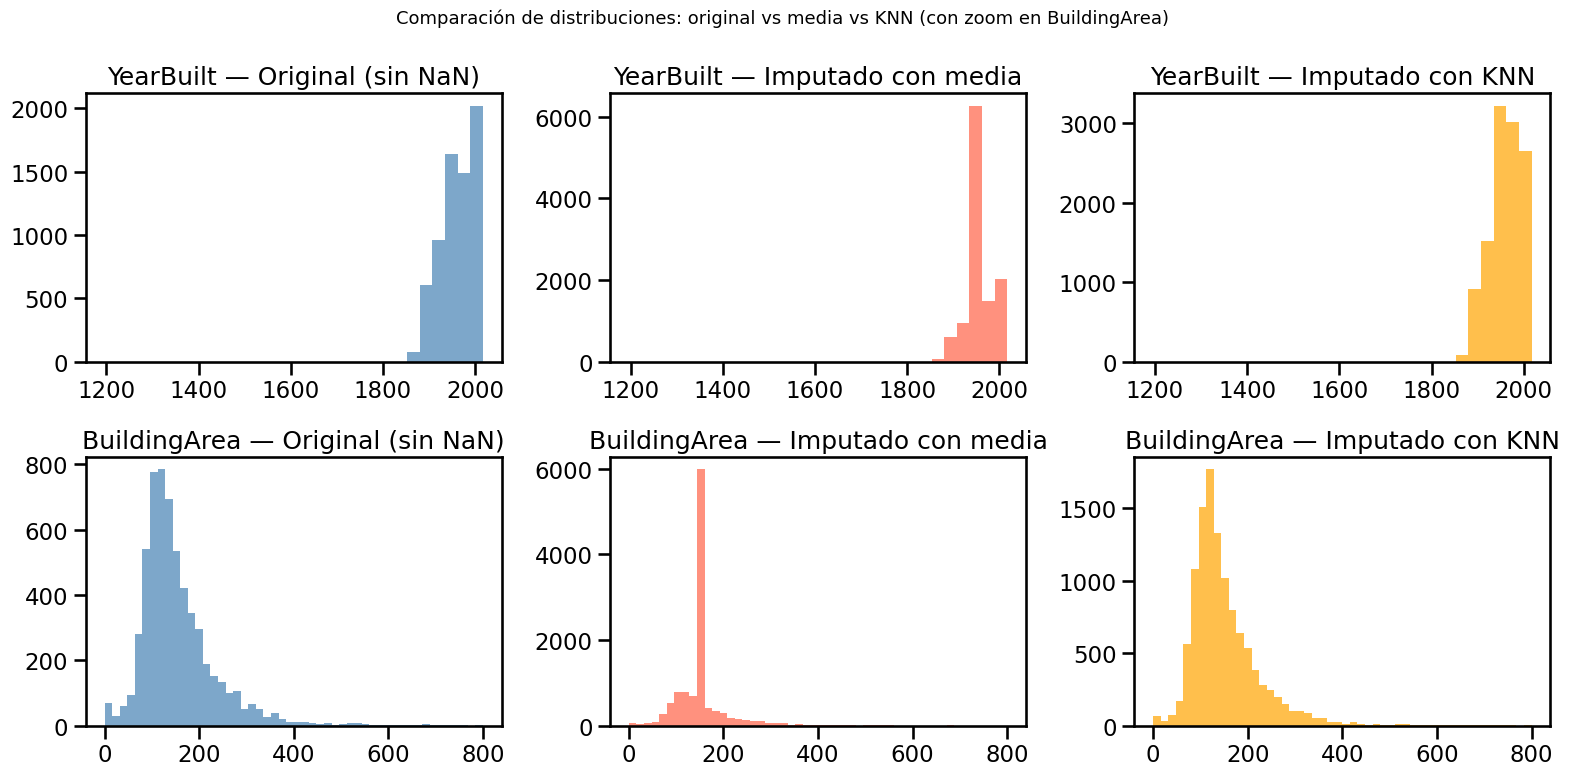

In [87]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

nombres = ['YearBuilt', 'BuildingArea']

# Índices de YearBuilt y BuildingArea en X_para_imputar
idx_year     = X_para_imputar.shape[1] - 2
idx_building = X_para_imputar.shape[1] - 1

for i, (nombre, idx) in enumerate(zip(nombres, [idx_year, idx_building])):
    col_min = scaler.data_min_[idx]
    col_max = scaler.data_max_[idx]

    valores_originales = extra[:, i]
    sin_nan            = valores_originales[~np.isnan(valores_originales)]
    valores_media      = X_imputed_mean[:, idx] * (col_max - col_min) + col_min
    valores_knn        = X_imputed[:, idx]      * (col_max - col_min) + col_min

    # Ampliamos el rango en BuildingArea
    rango      = (0, 800) if nombre == 'BuildingArea' else None
    bins_count = 50       if nombre == 'BuildingArea' else 30

    axes[i][0].hist(sin_nan,       bins=bins_count, range=rango, color='steelblue', alpha=0.7)
    axes[i][0].set_title(f'{nombre} — Original (sin NaN)')

    axes[i][1].hist(valores_media, bins=bins_count, range=rango, color='tomato',    alpha=0.7)
    axes[i][1].set_title(f'{nombre} — Imputado con media')

    axes[i][2].hist(valores_knn,   bins=bins_count, range=rango, color='orange',    alpha=0.7)
    axes[i][2].set_title(f'{nombre} — Imputado con KNN')

plt.suptitle('Comparación de distribuciones: original vs media vs KNN (con zoom en BuildingArea)', fontsize=13)
plt.tight_layout()
plt.show()

**Gráficos de YearBuilt**:


*  Original: distribución concentrada entre 1900  y 2000, con pico cerca de 2000.
*  Media: genera un pico gigante alrededor de 1970 (el promedio), distorsionando la distribución.
*   KNN: preserva la forma original, con la misma concentración hacia años más reciente.


**Gráficos de BuildingArea**:


*  Original: muy sesgada a la derecha, la mayoría de las propiedades tiene áreas pequeñas (entre 50 y 200 m2).
*  Media: pico en el valor promedio (150 m2), aplastando toda la variabilidad real.
*   KNN: mantiene la forma sesgada del original, distribuyendo los valores imputados.


A continuación, se grafica con gráficos de densidad, que nos permiten comparar la forma de las distribuciones de manera más suave y continua, sin depender del tamaño de los bins.

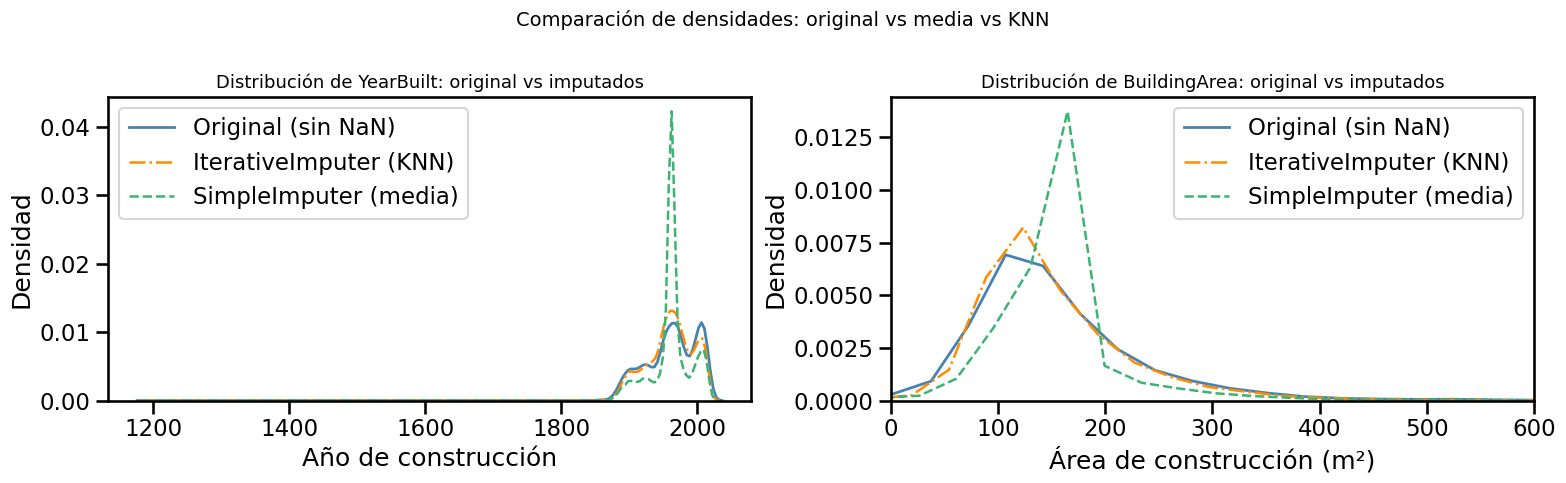

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Valores en escala original para graficar
idx_year     = X_para_imputar.shape[1] - 2
idx_building = X_para_imputar.shape[1] - 1

for idx in [idx_year, idx_building]:
    col_min = scaler.data_min_[idx]
    col_max = scaler.data_max_[idx]

i_year = idx_year
i_building = idx_building

# Valores originales (sin NaN)
year_original     = extra[:, 0][~np.isnan(extra[:, 0])]
building_original = extra[:, 1][~np.isnan(extra[:, 1])]

# Valores imputados con media (desescalados)
year_media     = X_imputed_mean[:, i_year]     * (scaler.data_max_[i_year]     - scaler.data_min_[i_year])     + scaler.data_min_[i_year]
building_media = X_imputed_mean[:, i_building] * (scaler.data_max_[i_building] - scaler.data_min_[i_building]) + scaler.data_min_[i_building]

# Valores imputados con KNN (desescalados)
year_knn     = X_imputed[:, i_year]     * (scaler.data_max_[i_year]     - scaler.data_min_[i_year])     + scaler.data_min_[i_year]
building_knn = X_imputed[:, i_building] * (scaler.data_max_[i_building] - scaler.data_min_[i_building]) + scaler.data_min_[i_building]

# Gráficos de densidad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# YearBuilt
sns.kdeplot(year_original, label='Original (sin NaN)', ax=axes[0],
            color='steelblue', linewidth=2)
sns.kdeplot(year_knn,      label='IterativeImputer (KNN)', ax=axes[0],
            color='darkorange', linewidth=1.8, linestyle='dashdot')
sns.kdeplot(year_media,    label='SimpleImputer (media)', ax=axes[0],
            color='mediumseagreen', linewidth=1.8, linestyle='dashed')

axes[0].set_title('Distribución de YearBuilt: original vs imputados', fontsize=13)
axes[0].set_xlabel('Año de construcción')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# BuildingArea
sns.kdeplot(building_original, label='Original (sin NaN)', ax=axes[1],
            color='steelblue', linewidth=2)
sns.kdeplot(building_knn,      label='IterativeImputer (KNN)', ax=axes[1],
            color='darkorange', linewidth=1.8, linestyle='dashdot')
sns.kdeplot(building_media,    label='SimpleImputer (media)', ax=axes[1],
            color='mediumseagreen', linewidth=1.8, linestyle='dashed')

axes[1].set_title('Distribución de BuildingArea: original vs imputados', fontsize=13)
axes[1].set_xlabel('Área de construcción (m²)')
axes[1].set_ylabel('Densidad')
axes[1].set_xlim(0, 600)
axes[1].legend()

plt.suptitle('Comparación de densidades: original vs media vs KNN', fontsize=14)
plt.tight_layout()
plt.show()

En ambos gráficos, se observa que la curva KNN es visualmente la más cercana a la original, lo que confirma que este método preserva la estructura de los datos.

**Conclusión**:

En lo gráficos se observa que la imputación con la media introduce un pico artificial en el valor promedio que no existía en la distribución, distorsionando la forma real de los datos. Esto visible principalmente 'YearBuilt', donde el pico de la media no refleja ningún patrón real.

La imputación con KNN, en cambio, preserva la forma general de ambas distribuciones y los valores imputados son coherentes con los datos existentes. Esto lo convierte en el método más adecuado cuando se quiere mantener la estructura del dataset.

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos? Puede decidir si hacer PCA sobre todas las variables o bien seleccionar un subconjunto que crea pertinente.

2. Seleccione las proyecciones de los datos sobre las dos primeras componentes principales (las primeras dos columnas del resultado) para agregar como nuevas características al conjunto de datos.

1.¿Es necesario escalar antes de PCA?

Sí. PCA busca las direcciones de mayor varianza en los datos. Si las variables tienen escalas muy distintas, aquellas con mayor magnitud pueden dominar el análisis, aunque no necesariamente sean más informativas.

En este caso, la matriz X_imputed ya fue escalada previamente con MinMaxScaler durante el ejercicio de imputación, por lo que las variables numéricas quedaron en el rango [0, 1]. Por este motivo, no fue necesario volver a escalar antes de aplicar PCA.

Aplicamos PCA sobre X_imputed, compuesta por las variables numéricas más YearBuilt y BuildingArea imputadas mediante KNN. Se decidió no incluir las variables categóricas codificadas con One-Hot Encoding porque, al ser variables binarias, pueden aumentar la dimensionalidad de la matriz y dificultar la interpretación de las componentes principales. Además, el objetivo principal fue analizar la estructura de variabilidad de las variables numéricas continuas.

In [89]:
from sklearn.decomposition import PCA

# Aplicamos PCA
# Definimos cuantos componentes principales vamos a calcular
n_components = min(20, X_imputed.shape[0], X_imputed.shape[1])

pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_imputed)

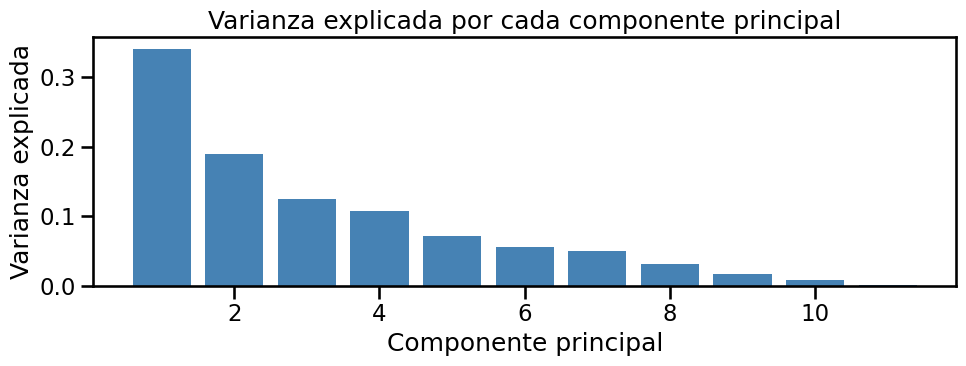

Varianza explicada por las 2 primeras componentes: 0.529
Shape PCA 2 componentes: (11423, 2)
[0.33947474 0.1895199  0.12466848 0.10793109 0.07200049 0.05631727
 0.05000452 0.03234946 0.0180073  0.00828717 0.00143959]


In [90]:
# Varianza explicada
plt.figure(figsize=(10, 4))

plt.bar(
    range(1, n_components + 1),
    pca.explained_variance_ratio_,
    color='steelblue'
)

plt.xlabel('Componente principal')
plt.ylabel('Varianza explicada')
plt.title('Varianza explicada por cada componente principal')
plt.tight_layout()
plt.show()

print(
    "Varianza explicada por las 2 primeras componentes:",
    round(pca.explained_variance_ratio_[:2].sum(), 3)
)

# Selección de las dos primeras componentes
X_pca_2 = X_pca[:, :2]

print("Shape PCA 2 componentes:", X_pca_2.shape)
print(pca.explained_variance_ratio_)

El gráfico muestra la proporción de varianza explicada por cada componente principal obtenida mediante PCA. La primera componente principal explica aproximadamente el 33,9% de la variabilidad total de los datos, mientras que la segunda componente explica aproximadamente el 19%.

En conjunto, las dos primeras componentes principales explican el 52,9% de la varianza total. Esto significa que, al reducir la matriz original de 11 variables a solo 2 componentes, se conserva un poco más de la mitad de la información contenida en las variables originales.

A partir de la tercera componente, la varianza explicada comienza a disminuir progresivamente. Esto indica que las primeras componentes concentran la mayor parte de la información, mientras que las componentes posteriores aportan cada vez menos variabilidad adicional.

Por este motivo, se seleccionaron las dos primeras componentes principales para incorporarlas al dataset como nuevas características, denominadas PCA_1 y PCA_2. La matriz resultante tiene dimensión (11423, 2), es decir, 11423 observaciones y 2 nuevas variables generadas por PCA.

In [91]:
# Agregamos PCA_1 y PCA_2 al dataset
melb_df_pca = melb_df.copy()

melb_df_pca['PCA_1'] = X_pca_2[:, 0]
melb_df_pca['PCA_2'] = X_pca_2[:, 1]

display(melb_df_pca[['PCA_1', 'PCA_2']].head())

,PCA_1,PCA_2
0,-0.140276,-0.231679
1,-0.138469,-0.280127
2,-0.149022,-0.169211
3,-0.148957,-0.143641
4,-0.151692,-0.096095


Las columnas PCA_1 y PCA_2 representan las coordenadas de cada observación en el nuevo espacio de componentes principales. Cada valor indica la proyección de una propiedad sobre las dos direcciones de mayor variabilidad encontradas por PCA. Estos valores no corresponden a variables originales del dataset, sino a combinaciones lineales de ellas. Por lo tanto, permiten resumir la información de las 11 variables numéricas originales en dos nuevas características.

In [92]:
# Nombres de las variables usadas en PCA
nombres_cols = numerical_col + ['YearBuilt', 'BuildingArea']

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=nombres_cols,
    columns=['Componente 1', 'Componente 2']
).round(3)

print("Loadings ordenados por Componente 1:")
display(loadings.sort_values('Componente 1', ascending=False))

Loadings ordenados por Componente 1:


,Componente 1,Componente 2
Propertycount,0.997,0.055
Lattitude,0.041,-0.266
Longtitude,0.033,0.315
BuildingArea,-0.004,0.040
YearBuilt,-0.007,0.067
Car,-0.012,0.356
Price,-0.015,0.160
Landsize,-0.016,0.275
Distance,-0.020,0.504
Bathroom,-0.037,0.391


La primera componente principal está explicada casi completamente por Propertycount. Esto significa que la mayor dirección de variabilidad encontrada por PCA está asociada principalmente a la cantidad de propiedades registradas en la zona.

La segunda componente principal está asociada principalmente a características físicas y de ubicación de las propiedades. Tiene pesos positivos altos en Distance, Rooms, Bathroom, Car y Landsize, por lo que puede interpretarse como una dimensión que combina distancia, tamaño y equipamiento de la vivienda.

Shape PCA 2 componentes: (11423, 2)


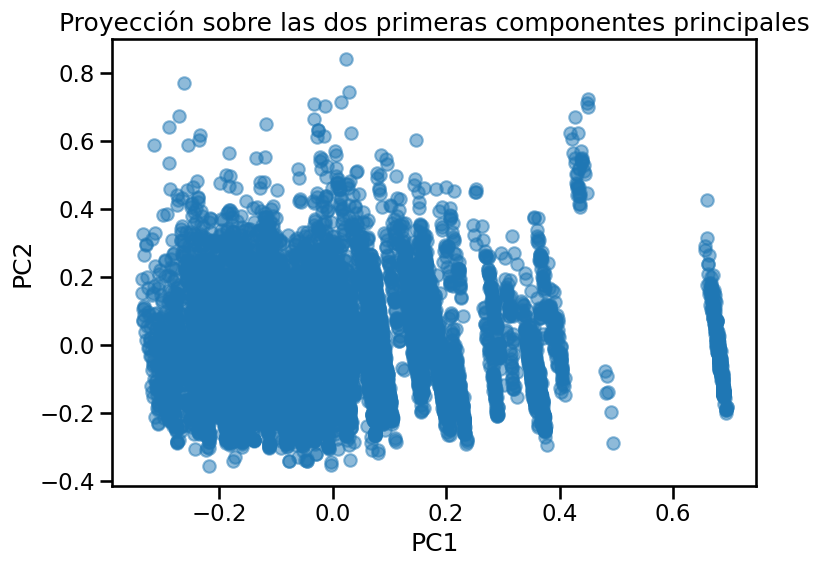

In [93]:
# Proyección sobre las dos primeras componentes
X_pca_2 = X_pca[:, :2]

print("Shape PCA 2 componentes:", X_pca_2.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección sobre las dos primeras componentes principales')
plt.tight_layout()
plt.show()

El gráfico representa la proyección de las propiedades sobre las dos primeras componentes principales. Cada punto corresponde a una observación del dataset. La mayor concentración de puntos se encuentra en valores bajos o cercanos a cero de PC1 y PC2, lo que indica que muchas propiedades presentan características similares en el espacio reducido.

Esta representación permite visualizar en dos dimensiones una parte importante de la estructura de los datos, dado que PC1 y PC2 explican en conjunto el 52,9% de la varianza total.

## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

In [94]:
# Recuperación de nombres de cada bloque de columnas
name_num = numerical_col + ['YearBuilt', 'BuildingArea']
name_cat = list(encoder.get_feature_names_out(categorical_col))
name_pca = ['PCA_1', 'PCA_2']

In [95]:
# Concatenado de nombres
name_cols = name_num + name_cat + name_pca
print(name_cols)

['Rooms', 'Price', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount', 'YearBuilt', 'BuildingArea', 'Type_h', 'Type_t', 'Type_u', 'Method_PI', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'Regionname_Eastern Metropolitan', 'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Regionname_Western Victoria', 'Semester_2016_S1', 'Semester_2016_S2', 'Semester_2017_S1', 'Semester_2017_S2', 'PCA_1', 'PCA_2']


In [96]:
# Concatenado de matrices: {numerica + ['YearBuilt', 'BuildingArea']} + categorica + PCA_2
matrix_final = np.hstack([matrix_num_col, matrix_cat, matrix_pca_2])
print(matrix_final.shape)

NameError: name 'matrix_num_col' is not defined

In [ ]:
# DataFrame cuasi-final
melb_df_final = pd.DataFrame(matrix_final, columns=name_cols)
melb_df_final.columns

In [ ]:
# Elimino las columnas asociadas al año y al mes
melb_df_final = melb_df_final.drop(['SaleYear', 'SaleMonth'], axis=1)
melb_df_final.columns

In [ ]:
# Exportar en archivo .csv
melb_df_final.to_csv('melb_data_processed.csv', index=False)
print("Shape final:", melb_df_final.shape)
print("\nArchivo guardado como melb_data_processed.csv")

In [ ]:
# Definimos los elementos a eliminar
correction = {'SaleYear', 'SaleMonth'}

# Creamos la lista filtrada
name_num_corrected = [col for col in name_num if col not in correction]

In [ ]:
# Primeras filas y columnas más relevantes
melb_df_final[name_num_corrected + name_cat + name_pca].sample(5).style\
    .format("{:.3f}")\
    .set_caption("Vista previa del DataFrame final — variables numéricas y PCA")\
    .background_gradient(cmap='Greens')

## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas o columnas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
